# Martian Spiders

In [18]:
import os
import sys
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes 
import pdb
import numpy as np
import os as os_module
from scipy.integrate import solve_ivp
import pandas as pd
from matplotlib import ticker
import scipy as sp
from scipy.integrate import cumulative_trapezoid, trapezoid, odeint, solve_bvp, solve_ivp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import colormaps
import matplotlib.ticker as mtick
from matplotlib.ticker import EngFormatter, LogLocator, FuncFormatter, NullFormatter, FixedLocator, StrMethodFormatter, LogFormatter, LogFormatterSciNotation, LogFormatterExponent, LogFormatterMathtext, FixedFormatter
from matplotlib.lines import lineStyles
import cmocean
import cmocean.cm as cmo
from matplotlib.colors import LogNorm
from IPython.display import clear_output
import matplotlib.patheffects as pe
from matplotlib.collections import LineCollection
from labellines import labelLines
from itertools import cycle

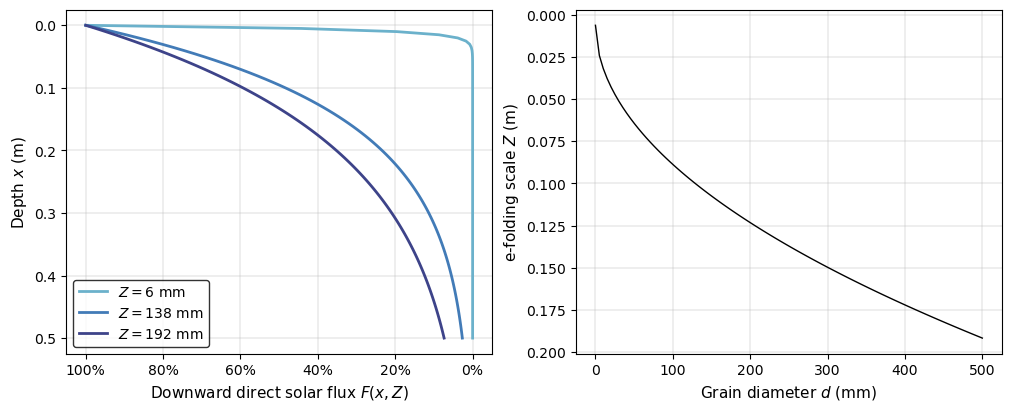

In [101]:
# Chinnerny et al. (2020) found e-folding of solar radiation penetration in CO2 ice relates to grain size in the following way.
 
a = 5.37 # (mm)
b_CO2 = 0.0144 # (mm)
d = np.linspace(1e-2, 500, 100) # grain diameter (mm)
x = np.linspace(0, 0.5, 100)*1e3 # depth (mm)

Z = a + np.sqrt(d/b_CO2) # e-folding scale 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# and downward direct energy flux F(x,Z) as a percentage of total radiation is given by
Z_0 = Z[0]
Z_50 = Z[50]
Z_99 = Z[99]
Zs = [Z_0, Z_50, Z_99]
colors = [cmo.ice(0.7), cmo.ice(0.5), cmo.ice(0.3)]
for z in Zs:
    F = np.exp(-x/z)
    ax1.plot(F*1e2, x/1e3, lw=2, color=colors[Zs.index(z)], label=f'$Z={z:.0f}$ mm')
ax1.set_ylabel('Depth $x$ (m)', fontsize=11)
ax1.set_xlabel('Downward direct solar flux $F(x,Z)$', fontsize=11)
ax1.xaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(lw=0.3)
ax1.invert_yaxis()
ax1.invert_xaxis()
ax1.legend(loc='lower left', fontsize=10, frameon=True, fancybox=True, edgecolor='black', facecolor='w')

ax2.plot(d, Z/1e3, color='k', lw=1)
ax2.set_xlabel('Grain diameter $d$ (mm)', fontsize=11)
ax2.set_ylabel('e-folding scale $Z$ (m)', fontsize=11)
ax2.grid(lw=0.3)
ax2.invert_yaxis()


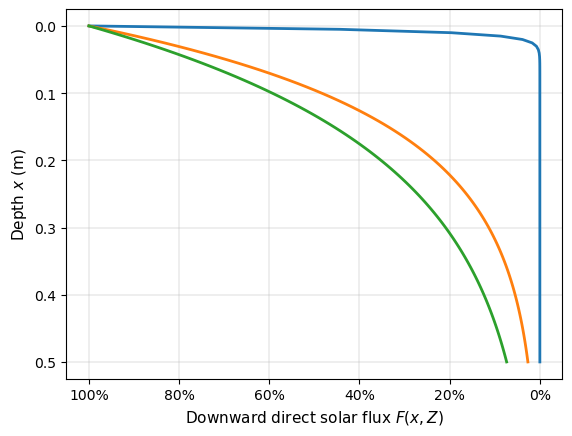

In [92]:
Z_0 = Z[0]
Z_50 = Z[50]
Z_99 = Z[99]
Zs = [Z_0, Z_50, Z_99]
colors = [cmo.ice(0.7), cmo.ice(0.5), cmo.ice(0.3)]
for z in Zs:
    F = np.exp(-x/z)
    plt.plot(F*1e2, x/1e3, lw=2)
plt.ylabel('Depth $x$ (m)', fontsize=11)
plt.xlabel('Downward direct solar flux $F(x,Z)$', fontsize=11)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter())
plt.grid(lw=0.3)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

In [ ]:
# CO2 ice slab thicknesses? 0.5-1 m.